# Employee Churn Benchmark — phase two

Evaluate departure classification and explain error patterns without causal claims.

The original-schema HR benchmark is retained: 11,991 unique, non-conflicting rows after cleanup. Its missing employee IDs, measurement dates, and departure horizon limit external validation. Random benchmark splits are appropriate for this demonstration, with future-company evaluation still outstanding.

This notebook executes the same standalone implementation; original notebooks are preserved.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from phase2 import run
summary = run()
summary

churn: selected random_forest_sigmoid; AP=0.9593; log loss=0.0763; elapsed=5.85s


{'project': 'churn',
 'input_file': 'hr.csv',
 'input_sha256': '2510e274a90547f34c7b0db5a4ab70282c2710eb54252f14921bf980b81a928c',
 'rows_read': 14999,
 'rows_used': 11991,
 'duplicates_removed': 3008,
 'conflicting_rows_removed': 0,
 'split_strategy': 'stratified 60/20/20 after deduplication',
 'selected_model': 'random_forest_sigmoid',
 'threshold': 0.691737847835872,
 'selection': 'validation log loss',
 'protocol': 'fit 45%, independent sigmoid calibration 15%, validation 20%, test 20%; grouped or chronological where available',
 'splits': {'fit': {'rows': 5395, 'positives': 896},
  'calibration': {'rows': 1799, 'positives': 299},
  'validation': {'rows': 2398, 'positives': 398},
  'test': {'rows': 2399, 'positives': 398}},
 'test': {'model': 'random_forest_sigmoid',
  'split': 'test',
  'average_precision': 0.9593313413142119,
  'roc_auc': 0.9818137413705207,
  'log_loss': 0.07633894470466364,
  'brier_score': 0.016533588501321965,
  'accuracy': 0.9808253438932889,
  'precision': 

In [2]:
display(pd.read_csv('results/phase2/metrics.csv'))

,model,split,average_precision,roc_auc,log_loss,brier_score,accuracy,precision,recall,f1,threshold,tn,fp,fn,tp,alerts,positive_rate,rows
0,baseline,validation,0.165972,0.500000,0.449441,0.138425,0.834028,0.000000,0.000000,0.000000,0.500000,2000,0,398,0,0,0.165972,2398
1,logistic_regression,validation,0.420582,0.830642,0.354551,0.112940,0.798165,0.436012,0.736181,0.547664,0.207503,1621,379,105,293,672,0.165972,2398
2,logistic_regression_sigmoid,validation,0.420582,0.830642,0.354680,0.112893,0.798165,0.436012,0.736181,0.547664,0.207432,1621,379,105,293,672,0.165972,2398
3,random_forest,validation,0.964726,0.983602,0.084628,0.018373,0.982902,0.986376,0.909548,0.946405,0.543918,1995,5,36,362,367,0.165972,2398
4,random_forest_sigmoid,validation,0.964726,0.983602,0.074649,0.015994,0.982902,0.986376,0.909548,0.946405,0.691738,1995,5,36,362,367,0.165972,2398
5,baseline,test,0.165902,0.500000,0.449329,0.138379,0.834098,0.000000,0.000000,0.000000,0.500000,2001,0,398,0,0,0.165902,2399
6,logistic_regression,test,0.394219,0.814775,0.366498,0.116821,0.789079,0.417683,0.688442,0.519924,0.207503,1619,382,124,274,656,0.165902,2399
7,logistic_regression_sigmoid,test,0.394219,0.814775,0.366260,0.116638,0.789079,0.417683,0.688442,0.519924,0.207432,1619,382,124,274,656,0.165902,2399
8,random_forest,test,0.959331,0.981814,0.088355,0.018851,0.980825,0.978261,0.904523,0.939948,0.543918,1993,8,38,360,368,0.165902,2399
9,random_forest_sigmoid,test,0.959331,0.981814,0.076339,0.016534,0.980825,0.978261,0.904523,0.939948,0.691738,1993,8,38,360,368,0.165902,2399


In [3]:
display(Markdown(Path('results/phase2/REPORT.md').read_text()))

# Phase two: evidence and decision trade-offs

11,991 deduplicated observations. **random_forest_sigmoid** was selected using validation log loss.
fit 45%, independent sigmoid calibration 15%, validation 20%, test 20%; grouped or chronological where available. Calibration uses disjoint reserve labels; preprocessing fits only on fit rows.

| Test measure | Selected | Prior baseline |
|---|---:|---:|
| Average precision | 0.9593 | 0.1659 |
| Log loss | 0.0763 | 0.4493 |
| Brier score | 0.0165 | 0.1384 |
| Precision | 97.8% | 0.0% |
| Recall | 90.5% | 0.0% |

At the validation-selected threshold, 360 positives are found, 38 are missed, and 8 false flags occur.
95% Wilson recall interval: 87.2%–93.0%; precision: 95.8%–98.9%.
The intervals describe this benchmark sample under the stated sampling assumptions.

![Calibration reliability and bin support](reliability.png)
![Ranking budget and captured positives](ranking.png)

[Operating policies](operating_policies.csv) choose thresholds exclusively from validation scores for fixed workload budgets.
Ties stay together and can leave a budget partly unused. Applying the same thresholds to test can exceed the validation budget;
the table records actual counts. No dollar-saving or intervention-effect claim is inferred from these retrospective labels.

[Uncertainty](uncertainty.json) contains 200 bootstrap replicates, with clusters resampled when user/context groups exist.
[Validation stability](validation_stability.csv) tests a fixed model structure on three development-only splits.
[Subgroup errors](subgroup_errors.csv) gives support and missed/false-flag counts; small groups warrant caution.
[Error rows](errors.csv), [all candidate metrics](metrics.csv), [test predictions](predictions.csv), and [partition membership](splits.csv) are auditable.

The final test labels are not used to choose calibration, models, budgets, or thresholds. Previously published benchmark results
were known during redevelopment; an independent external evaluation remains necessary. Calibration assumes the same target population.
For CTR, calibration cannot undo unknown upstream negative sampling. For HR, observation dates and a departure horizon are missing;
feature-importance consistency is association, not causality. The fraud benchmark spans two days and anonymized PCA features.


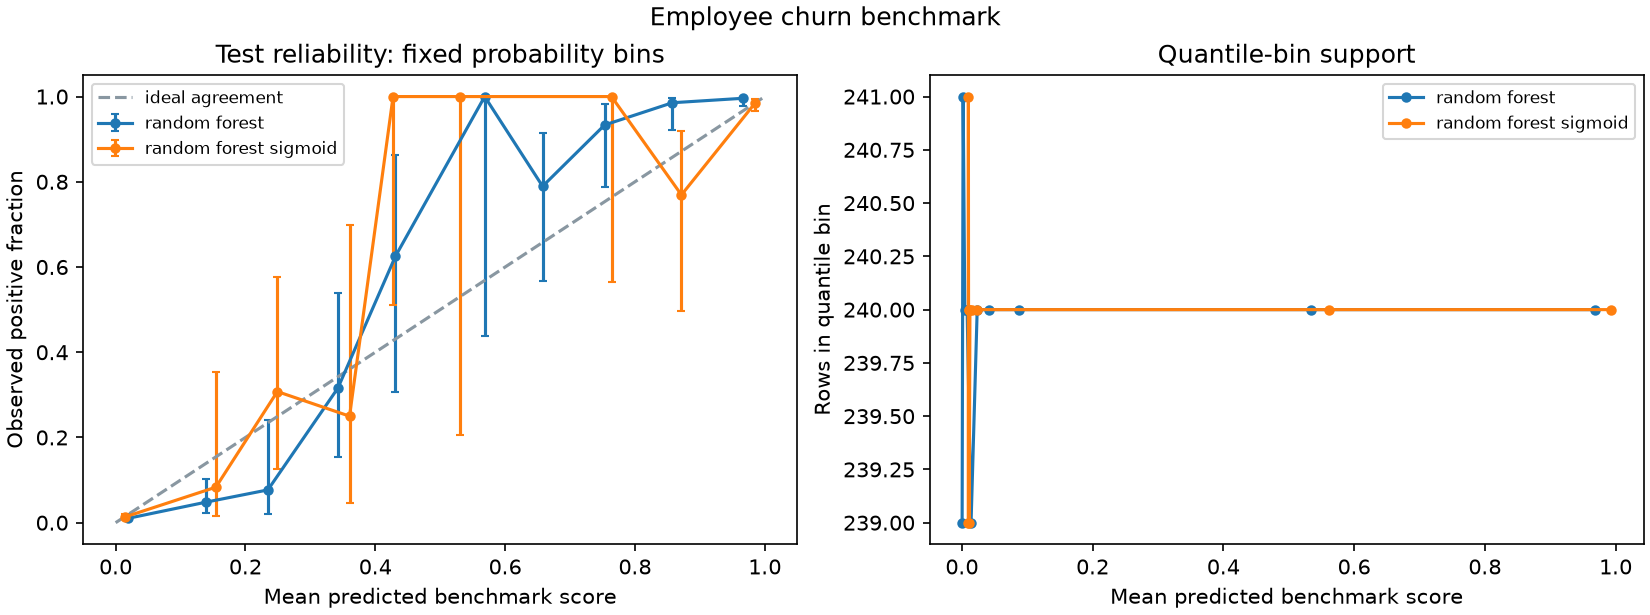

,fold,fit_rows,calibration_rows,validation_rows,average_precision,roc_auc,log_loss,brier_score,accuracy,precision,recall,f1,threshold,tn,fp,fn,tp,alerts,positive_rate,rows
0,1,5395,1799,2398,0.964825,0.981830,0.079711,0.017664,0.980817,0.960733,0.922111,0.941026,0.277949,1985,15,31,367,382,0.165972,2398
1,2,5395,1799,2398,0.963268,0.980700,0.076747,0.016198,0.983319,0.983784,0.914573,0.947917,0.619212,1994,6,34,364,370,0.165972,2398
2,3,5395,1799,2398,0.959195,0.977307,0.080644,0.017661,0.981651,0.983607,0.904523,0.942408,0.694581,1994,6,38,360,366,0.165972,2398


In [4]:
display(Image(filename='results/phase2/reliability.png'))
display(pd.read_csv('results/phase2/validation_stability.csv'))

In [5]:
json.loads(Path('results/phase2/uncertainty.json').read_text())

{'level': 0.95,
 'method': 'Class-stratified row bootstrap; conditional on observed class counts',
 'replicates': 200,
 'intervals': {'average_precision': {'low': 0.9368865668484294,
   'high': 0.9746526392187426},
  'f1': {'low': 0.9216415297531577, 'high': 0.9536272328929153},
  'log_loss': {'low': 0.06047498789727523, 'high': 0.09653076507224834}},
 'recall_wilson': {'estimate': 0.9045226130653267,
  'low': 0.8716634792679547,
  'high': 0.9296475674940963,
  'n': 398},
 'precision_wilson': {'estimate': 0.9782608695652174,
  'low': 0.9576958287755284,
  'high': 0.9889441750486234,
  'n': 368},
 'limits': 'Wilson intervals assume independent rows; cluster bootstrap is used when IDs exist. Neither method establishes future-domain performance or accounts for two-day temporal dependence.'}

In [6]:
display(pd.read_csv('results/phase2/errors.csv').head(10))

,row_id,actual,selected_score,predicted,baseline_score,logistic_regression_score,logistic_regression_sigmoid_score,random_forest_score,random_forest_sigmoid_score,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary
0,1747,1,0.015788,0,0.16608,0.226668,0.226014,0.048862,0.015788,0.63,0.76,2,157,4,0,0,RandD,low
1,621,1,0.291132,0,0.16608,0.698078,0.684364,0.373769,0.291132,0.10,0.55,2,247,4,0,0,sales,medium
2,105,1,0.078828,0,0.16608,0.266763,0.264798,0.216612,0.078828,0.24,0.46,7,224,5,0,0,accounting,medium
3,122,1,0.489372,0,0.16608,0.325617,0.321598,0.458673,0.489372,0.75,1.00,4,216,6,0,0,technical,low
4,3881,0,0.890720,1,0.16608,0.058705,0.061047,0.673159,0.890720,0.42,0.56,2,103,3,1,0,marketing,medium
5,925,1,0.022789,0,0.16608,0.382731,0.376680,0.086352,0.022789,0.46,0.86,2,212,4,0,0,sales,medium
6,568,1,0.013830,0,0.16608,0.405329,0.398486,0.035394,0.013830,0.25,0.46,4,214,4,0,0,technical,medium
7,1570,1,0.011426,0,0.16608,0.206659,0.206613,0.016017,0.011426,0.60,0.85,3,250,2,0,0,support,low
8,1603,1,0.058424,0,0.16608,0.014206,0.015440,0.184403,0.058424,0.85,1.00,6,260,3,1,0,management,low
9,5556,0,0.923618,1,0.16608,0.096549,0.098825,0.712680,0.923618,0.84,0.84,6,261,5,0,0,product_mng,low


In [7]:
display(pd.read_csv('results/phase2/importance_stability.csv'))
display(pd.read_csv('results/phase2/subgroup_errors.csv').head(12))

,feature,mean_rank,rank_std,mean_ap_decrease
0,satisfaction_level,1.000000,0.000000,0.294893
1,time_spend_company,2.000000,0.000000,0.115924
2,number_project,3.000000,0.000000,0.098673
3,average_montly_hours,4.000000,0.000000,0.069510
4,last_evaluation,5.000000,0.000000,0.055743
5,Work_accident,6.666667,0.577350,0.000837
6,salary,6.666667,1.154701,0.001998
7,promotion_last_5years,8.000000,1.000000,-0.000098
8,department,8.666667,0.577350,-0.000753


,feature,group,rows,positives,false_positives,false_negatives,brier_score
0,department,IT,190,23,0,0,0.000625
1,department,RandD,144,15,0,2,0.014412
2,department,accounting,120,22,0,2,0.016050
3,department,hr,123,22,0,2,0.016105
4,department,management,88,8,1,1,0.022240
5,department,marketing,153,22,1,2,0.018014
6,department,product_mng,135,25,1,1,0.012730
7,department,sales,657,114,2,12,0.017328
8,department,support,343,69,0,6,0.015836
9,department,technical,446,78,3,10,0.023127


## Interpretation

Three development-only validation splits compare fixed-model performance and permutation-importance ranks. `importance_stability.csv` reports mean rank and variation. `subgroup_errors.csv` shows missed departures and false flags by department, salary, and satisfaction band. These groups describe model behavior; they do not establish equitable treatment or intervention effectiveness.

Read `FEATURE_AVAILABILITY.md` before adapting the model to a company. All fields need a documented pre-departure measurement window. A validated prediction horizon requires dated employee snapshots and departure events, which this benchmark does not contain.